# LoRA: Parameter-Efficient Identity Personalization

This notebook is the fourth experiment in the Stable Diffusion personalization study.

LoRA sits between Textual Inversion and DreamBooth in adaptation capacity. Instead of updating the full model, I train low-rank adapters for the diffusion model and text encoder.

I compare the base checkpoint with the same pipeline after loading the identity LoRA, then test the adapter together with OpenPose ControlNet.


## 1. LoRA Training


In [1]:
!curl -O https://raw.githubusercontent.com/huggingface/diffusers/v0.29.2/examples/dreambooth/train_dreambooth_lora.py


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 57402  100 57402    0     0  79049      0 --:--:-- --:--:-- --:--:-- 78957


I train the adapters on the same identity dataset and use the same `sks person` instance token as in the DreamBooth experiment.


In [1]:
%%bash
python3 ./train_dreambooth_lora.py \
--pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
--instance_data_dir=./jortega \
--instance_prompt="a photo of a sks person" \
--class_prompt="a photo of a person" \
--class_data_dir=./class_person \
--with_prior_preservation \
--output_dir=./sd15_lora_jortega \
--seed=42 \
--train_text_encoder \
--resolution=512 \
--train_batch_size=1 \
--dataloader_num_workers=1 \
--max_train_steps=5000 \
--gradient_accumulation_steps=1 \
--gradient_checkpointing \
--learning_rate=3e-4 \
--mixed_precision=fp16 \
--checkpointing_steps=1000 \
--max_grad_norm=1.0 \
--rank=128 \
--lr_scheduler="cosine" \
--lr_warmup_steps=500


/home/jovyan/.local/lib/python3.12/site-packages/accelerate/accelerator.py:529: UserWarning: `log_with=tensorboard` was passed but no supported trackers are currently installed.
  warnings.warn(f"`log_with={log_with}` was passed but no supported trackers are currently installed.")
09/05/2026 14:47:28 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
{'clip_sample_range', 'sample_max_value', 'timestep_spacing', 'prediction_type', 'variance_type', 'rescale_betas_zero_snr', 'dynamic_thresholding_ratio', 'thresholding'} was not found in config. Values will be initialized to default values.
{'mid_block_add_attention', 'force_upcast', 'use_quant_conv', 'shift_factor', 'latents_mean', 'latents_std', 'use_post_quant_conv

## 2. Base-Model Generation

I first generate from the base checkpoint before loading the trained adapter. This gives a direct visual reference for the effect of the LoRA weights.


In [2]:
import torch
import requests
from io import BytesIO

import cv2
import numpy as np
from PIL import Image
from IPython.display import display

from diffusers import AutoencoderKL, ControlNetModel, EulerAncestralDiscreteScheduler
from diffusers import StableDiffusionPipeline, StableDiffusionControlNetPipeline, UNet2DConditionModel

from controlnet_aux import OpenposeDetector
from transformers import CLIPTextModel

In [6]:
device = torch.device("cuda")
dtype = torch.bfloat16

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype=dtype, use_safetensors=True),
    torch_dtype=dtype,
    safety_checker=None,
    use_safetensors=True
).to(device, dtype)

pipe_scheduler_config = pipe.scheduler.config
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe_scheduler_config)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/50 [00:00<?, ?it/s]

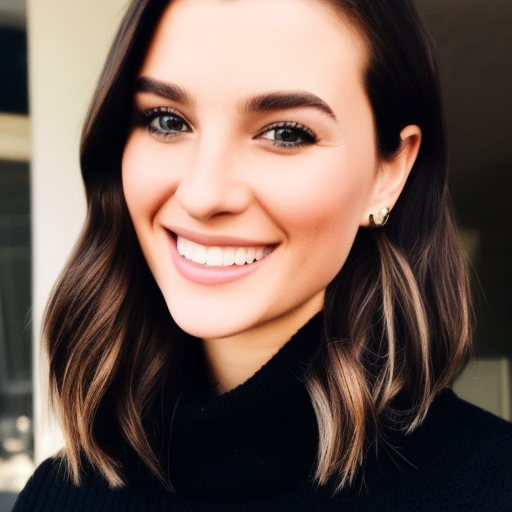

In [7]:
img = pipe(
    prompt="instagram photo, closeup face photo of sks person in black sweater, pale skin, smile, hard shadows",
    negative_prompt="nsfw, naked, nude, deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime, mutated hands and fingers, deformed, distorted, disfigured, poorly drawn, bad anatomy, wrong anatomy, extra limb, missing limb, floating limbs, disconnected limbs, mutation, mutated, ugly, disgusting, amputation",
    height=512, width=512,
    num_inference_steps=50,
    guidance_scale=7.0,
    generator=torch.Generator(device=device).manual_seed(42),
).images[0]

img


## 3. LoRA Identity Generation

I load the trained LoRA weights into the same pipeline and apply them to both the U-Net and text encoder.


In [9]:
pipe.load_lora_weights(
    "./sd15_lora_jortega",
    weight_name="pytorch_lora_weights.safetensors",
    adapter_name="jortega",
)


In [10]:
pipe.set_adapters(
    "jortega",
    {
        "text_encoder": 1.0,
        "unet": 1.0,
    }
)


  0%|          | 0/50 [00:00<?, ?it/s]

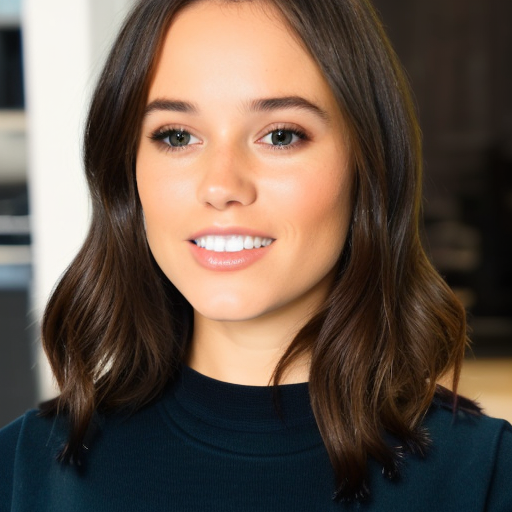

In [11]:
img = pipe(
    prompt="instagram photo, closeup face photo of sks person in black sweater, pale skin, smile, hard shadows",
    negative_prompt="nsfw, naked, nude, deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime, mutated hands and fingers, deformed, distorted, disfigured, poorly drawn, bad anatomy, wrong anatomy, extra limb, missing limb, floating limbs, disconnected limbs, mutation, mutated, ugly, disgusting, amputation",
    height=512, width=512,
    num_inference_steps=50,
    guidance_scale=7.0,
    generator=torch.Generator(device=device).manual_seed(42),
).images[0]

img


### Observation

The adapter moves the generation toward the target identity while keeping the base checkpoint intact. The broad appearance transfers well, although fine facial details remain less consistent than the strongest identity-conditioning result.


## 4. Pose-Controlled Generation

Finally, I load the same LoRA into a ControlNet pipeline and add the reference pose. This tests how well the parameter-efficient adaptation survives an additional structural condition.


In [12]:
pose_detector = OpenposeDetector.from_pretrained("lllyasviel/ControlNet")


/home/jovyan/.local/lib/python3.12/site-packages/controlnet_aux/open_pose/body.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = util.transfer(self.model, to

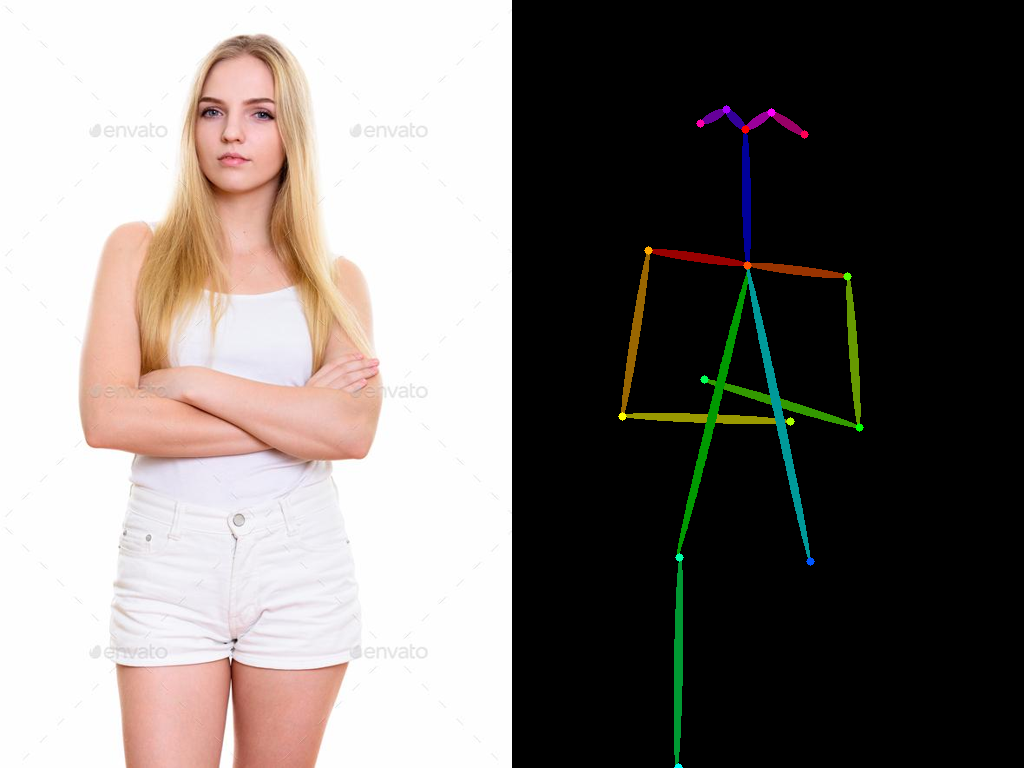

In [13]:
url = "https://s3.envato.com/files/287416893/23rdJanuary2017-4.jpg"
response = requests.get(url)
Image.open(BytesIO(response.content)).save("photo.jpg")
pose = pose_detector(Image.open("photo.jpg"))

Image.fromarray(np.hstack((
    np.asarray(Image.open("photo.jpg").resize((pose.width, pose.height))),
    np.asarray(pose),
)))


In [14]:
controlnet_pose = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-openpose", torch_dtype=torch.float16).to(device)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",    
    controlnet=controlnet_pose,
    vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype=dtype, use_safetensors=True),
    torch_dtype=dtype,
    safety_checker=None,
    use_safetensors=True
).to(device, dtype)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [15]:
pipe.load_lora_weights(
    "./sd15_lora_jortega",
    weight_name="pytorch_lora_weights.safetensors",
    adapter_name="jortega",
)

pipe.set_adapters("jortega", {"text_encoder": 1.0, "unet": 1.0,})

  0%|          | 0/50 [00:00<?, ?it/s]

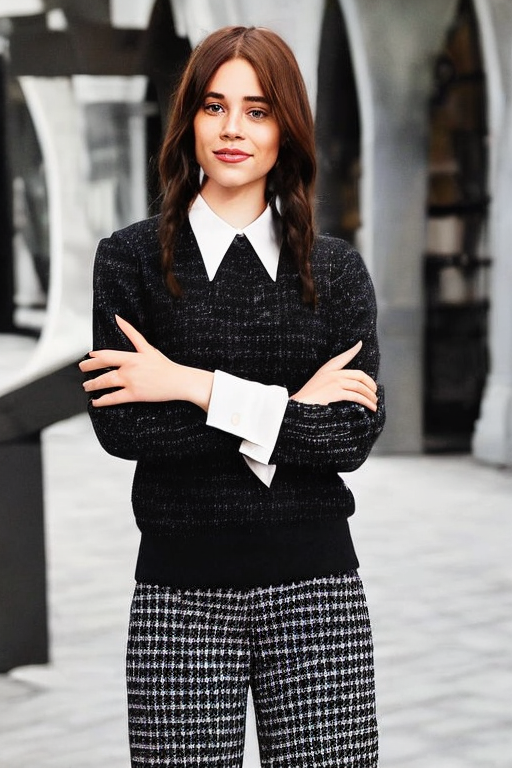

In [16]:
img = pipe(
    prompt="instagram photo, closeup face photo of sks person in black sweater, pale skin, smile, hard shadows",
    negative_prompt="nsfw, naked, nude, deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime, mutated hands and fingers, deformed, distorted, disfigured, poorly drawn, bad anatomy, wrong anatomy, extra limb, missing limb, floating limbs, disconnected limbs, mutation, mutated, ugly, disgusting, amputation",
    guidance_scale=7.0,
    height=pose.height, width=pose.width,
    num_inference_steps=50,
    image=pose,
).images[0]

img

### Observation

The result keeps some of the learned appearance, but exact identity similarity becomes weaker once pose conditioning is added. In this setup, LoRA provides a practical middle ground between a tiny learned embedding and full DreamBooth fine-tuning.
